#**Preparación de los datos ⚒**

##**Extracción del archivo tratado**

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
datos = pd.read_csv('/content/datos_tratados.csv')
datos.shape

(7267, 21)

In [70]:
datos.isnull().count()

,0
customerID,7267
Churn,7267
gender,7267
SeniorCitizen,7267
Partner,7267
Dependents,7267
tenure,7267
PhoneService,7267
MultipleLines,7267
InternetService,7267


In [71]:
datos.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')

##**Eliminación de columnas irrelevantes**

In [72]:
datos

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,False,Female,0,True,True,9,True,False,DSL,...,True,False,True,True,False,One year,True,Mailed check,65.60,593.30
1,0003-MKNFE,False,Male,0,False,False,9,True,True,DSL,...,False,False,False,False,True,Month-to-month,False,Mailed check,59.90,542.40
2,0004-TLHLJ,True,Male,0,False,False,4,True,False,Fiber optic,...,False,True,False,False,False,Month-to-month,True,Electronic check,73.90,280.85
3,0011-IGKFF,True,Male,1,True,False,13,True,False,Fiber optic,...,True,True,False,True,True,Month-to-month,True,Electronic check,98.00,1237.85
4,0013-EXCHZ,True,Female,1,True,False,3,True,False,Fiber optic,...,False,False,True,True,False,Month-to-month,True,Mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,False,Female,0,False,False,13,True,False,DSL,...,False,False,True,False,False,One year,False,Mailed check,55.15,742.90
7263,9992-RRAMN,True,Male,0,True,False,22,True,True,Fiber optic,...,False,False,False,False,True,Month-to-month,True,Electronic check,85.10,1873.70
7264,9992-UJOEL,False,Male,0,False,False,2,True,False,DSL,...,True,False,False,False,False,Month-to-month,True,Mailed check,50.30,92.75
7265,9993-LHIEB,False,Male,0,True,True,67,True,False,DSL,...,False,True,True,False,True,Two year,False,Mailed check,67.85,4627.65


In [73]:
df_nuevo = datos.drop(columns=['customerID'])
df_nuevo

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,False,Female,0,True,True,9,True,False,DSL,False,True,False,True,True,False,One year,True,Mailed check,65.60,593.30
1,False,Male,0,False,False,9,True,True,DSL,False,False,False,False,False,True,Month-to-month,False,Mailed check,59.90,542.40
2,True,Male,0,False,False,4,True,False,Fiber optic,False,False,True,False,False,False,Month-to-month,True,Electronic check,73.90,280.85
3,True,Male,1,True,False,13,True,False,Fiber optic,False,True,True,False,True,True,Month-to-month,True,Electronic check,98.00,1237.85
4,True,Female,1,True,False,3,True,False,Fiber optic,False,False,False,True,True,False,Month-to-month,True,Mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,False,Female,0,False,False,13,True,False,DSL,True,False,False,True,False,False,One year,False,Mailed check,55.15,742.90
7263,True,Male,0,True,False,22,True,True,Fiber optic,False,False,False,False,False,True,Month-to-month,True,Electronic check,85.10,1873.70
7264,False,Male,0,False,False,2,True,False,DSL,False,True,False,False,False,False,Month-to-month,True,Mailed check,50.30,92.75
7265,False,Male,0,True,True,67,True,False,DSL,True,False,True,True,False,True,Two year,False,Mailed check,67.85,4627.65


##**Normalización de datos**

In [74]:
df_nuevo = df_nuevo.rename(columns={'Churn':'cancelo','gender':'genero','SeniorCitizen':'mayor_de_65','tenure':'meses_de_contrato','Contract':'tiempo_contrato','Charges.Monthly':'gasto_mensual','Charges.Total':'gasto_total'})
df_nuevo

,cancelo,genero,mayor_de_65,Partner,Dependents,meses_de_contrato,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,tiempo_contrato,PaperlessBilling,PaymentMethod,gasto_mensual,gasto_total
0,False,Female,0,True,True,9,True,False,DSL,False,True,False,True,True,False,One year,True,Mailed check,65.60,593.30
1,False,Male,0,False,False,9,True,True,DSL,False,False,False,False,False,True,Month-to-month,False,Mailed check,59.90,542.40
2,True,Male,0,False,False,4,True,False,Fiber optic,False,False,True,False,False,False,Month-to-month,True,Electronic check,73.90,280.85
3,True,Male,1,True,False,13,True,False,Fiber optic,False,True,True,False,True,True,Month-to-month,True,Electronic check,98.00,1237.85
4,True,Female,1,True,False,3,True,False,Fiber optic,False,False,False,True,True,False,Month-to-month,True,Mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,False,Female,0,False,False,13,True,False,DSL,True,False,False,True,False,False,One year,False,Mailed check,55.15,742.90
7263,True,Male,0,True,False,22,True,True,Fiber optic,False,False,False,False,False,True,Month-to-month,True,Electronic check,85.10,1873.70
7264,False,Male,0,False,False,2,True,False,DSL,False,True,False,False,False,False,Month-to-month,True,Mailed check,50.30,92.75
7265,False,Male,0,True,True,67,True,False,DSL,True,False,True,True,False,True,Two year,False,Mailed check,67.85,4627.65


In [75]:
df_nuevo['tiempo_contrato']=df_nuevo['tiempo_contrato'].replace({'One year':'Un año','Two year':'Dos años','Month-to-month':'Cada mes'})
df_nuevo['cancelo']=df_nuevo['cancelo'].replace({'No':False,'Si':True})
df_nuevo['mayor_de_65']=df_nuevo['mayor_de_65'].replace({'No':False,'Si':True})
df_nuevo

,cancelo,genero,mayor_de_65,Partner,Dependents,meses_de_contrato,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,tiempo_contrato,PaperlessBilling,PaymentMethod,gasto_mensual,gasto_total
0,False,Female,0,True,True,9,True,False,DSL,False,True,False,True,True,False,Un año,True,Mailed check,65.60,593.30
1,False,Male,0,False,False,9,True,True,DSL,False,False,False,False,False,True,Cada mes,False,Mailed check,59.90,542.40
2,True,Male,0,False,False,4,True,False,Fiber optic,False,False,True,False,False,False,Cada mes,True,Electronic check,73.90,280.85
3,True,Male,1,True,False,13,True,False,Fiber optic,False,True,True,False,True,True,Cada mes,True,Electronic check,98.00,1237.85
4,True,Female,1,True,False,3,True,False,Fiber optic,False,False,False,True,True,False,Cada mes,True,Mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,False,Female,0,False,False,13,True,False,DSL,True,False,False,True,False,False,Un año,False,Mailed check,55.15,742.90
7263,True,Male,0,True,False,22,True,True,Fiber optic,False,False,False,False,False,True,Cada mes,True,Electronic check,85.10,1873.70
7264,False,Male,0,False,False,2,True,False,DSL,False,True,False,False,False,False,Cada mes,True,Mailed check,50.30,92.75
7265,False,Male,0,True,True,67,True,False,DSL,True,False,True,True,False,True,Dos años,False,Mailed check,67.85,4627.65


##**Verificación de la proporción de cancelación (Churn)**

In [76]:
print(f'Los usuarios que han cancelado \n{df_nuevo['cancelo'].value_counts('Si')*100}')

Los usuarios que han cancelado 
cancelo
False    73.463013
True     26.536987
Name: proportion, dtype: float64


In [77]:
df_nuevo['cancelo']=df_nuevo['cancelo'].replace({False:'0',True:'1'})

df_nuevo['cancelo'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7267 entries, 0 to 7266
Series name: cancelo
Non-Null Count  Dtype 
--------------  ----- 
7043 non-null   object
dtypes: object(1)
memory usage: 56.9+ KB


##**Encoding**

In [78]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from pandas.core.reshape.encoding import get_dummies
le = LabelEncoder()
scaler = StandardScaler()

In [79]:
df_limpio=df_nuevo.copy()

In [80]:
df_limpio['cancelo']=pd.to_numeric(df_limpio['cancelo'], errors='coerce').fillna(0).astype(int)

In [81]:
#encoding columnas booleanas

cols_bool = df_limpio.select_dtypes(include=['bool']).columns
df_limpio[cols_bool] = df_limpio[cols_bool].astype(int)

In [82]:
#encoding columnas categóricas

df_limpio['genero'] = df_limpio['genero'].map({'Male': 0, 'Female': 1})

#Para el resto de los objetos
df_final = pd.get_dummies(df_limpio, columns=['InternetService', 'OnlineSecurity', 'tiempo_contrato', 'PaymentMethod'], drop_first=True)

In [83]:
df_final

,cancelo,genero,mayor_de_65,Partner,Dependents,meses_de_contrato,PhoneService,MultipleLines,OnlineBackup,DeviceProtection,...,gasto_total,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_True,tiempo_contrato_Dos años,tiempo_contrato_Un año,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,1,9,1,0,1,0,...,593.30,False,False,False,False,False,True,False,False,True
1,0,0,0,0,0,9,1,1,0,0,...,542.40,False,False,False,False,False,False,False,False,True
2,1,0,0,0,0,4,1,0,0,1,...,280.85,True,False,False,False,False,False,False,True,False
3,1,0,1,1,0,13,1,0,1,1,...,1237.85,True,False,False,False,False,False,False,True,False
4,1,1,1,1,0,3,1,0,0,0,...,267.40,True,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,0,1,0,0,0,13,1,0,0,0,...,742.90,False,False,False,True,False,True,False,False,True
7263,1,0,0,1,0,22,1,1,0,0,...,1873.70,True,False,False,False,False,False,False,True,False
7264,0,0,0,0,0,2,1,0,1,0,...,92.75,False,False,False,False,False,False,False,False,True
7265,0,0,0,1,1,67,1,0,0,1,...,4627.65,False,False,False,True,True,False,False,False,True


#**Correlación y selección de variables 🎯**

##**Análisis de correlación**

Matriz de la correlación de los datos normalizados y tratados en encoding

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

In [85]:
corr_matrix = df_final.corr()
corr_matrix.head()

,cancelo,genero,mayor_de_65,Partner,Dependents,meses_de_contrato,PhoneService,MultipleLines,OnlineBackup,DeviceProtection,...,gasto_total,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_True,tiempo_contrato_Dos años,tiempo_contrato_Un año,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
cancelo,1.000000,0.009555,0.146733,-0.148546,-0.161384,-0.344079,0.012571,0.039343,-0.080163,-0.063452,...,-0.193345,0.300949,-0.224051,-0.224051,-0.166828,-0.295138,-0.173958,-0.131085,0.294626,-0.090061
genero,0.009555,1.000000,0.004288,0.005007,-0.012038,-0.005765,0.005073,0.007805,0.013494,0.002740,...,-0.000367,0.009572,-0.006318,-0.006318,0.016974,0.005449,-0.007328,-0.000700,-0.002060,-0.015057
mayor_de_65,0.146733,0.004288,1.000000,0.022970,-0.212952,0.018187,0.010060,0.144567,0.068824,0.060358,...,0.104076,0.255271,-0.182697,-0.182697,-0.037953,-0.114837,-0.046832,-0.022698,0.170705,-0.154216
Partner,-0.148546,0.005007,0.022970,1.000000,0.448900,0.377551,0.018828,0.141187,0.139523,0.153209,...,0.315409,0.002678,0.000419,0.000419,0.141392,0.246472,0.081021,0.081613,-0.079629,-0.097648
Dependents,-0.161384,-0.012038,-0.212952,0.448900,1.000000,0.159892,-0.003863,-0.027894,0.023686,0.014797,...,0.061474,-0.168028,0.142274,0.142274,0.083951,0.203136,0.068755,0.061608,-0.151749,0.060222


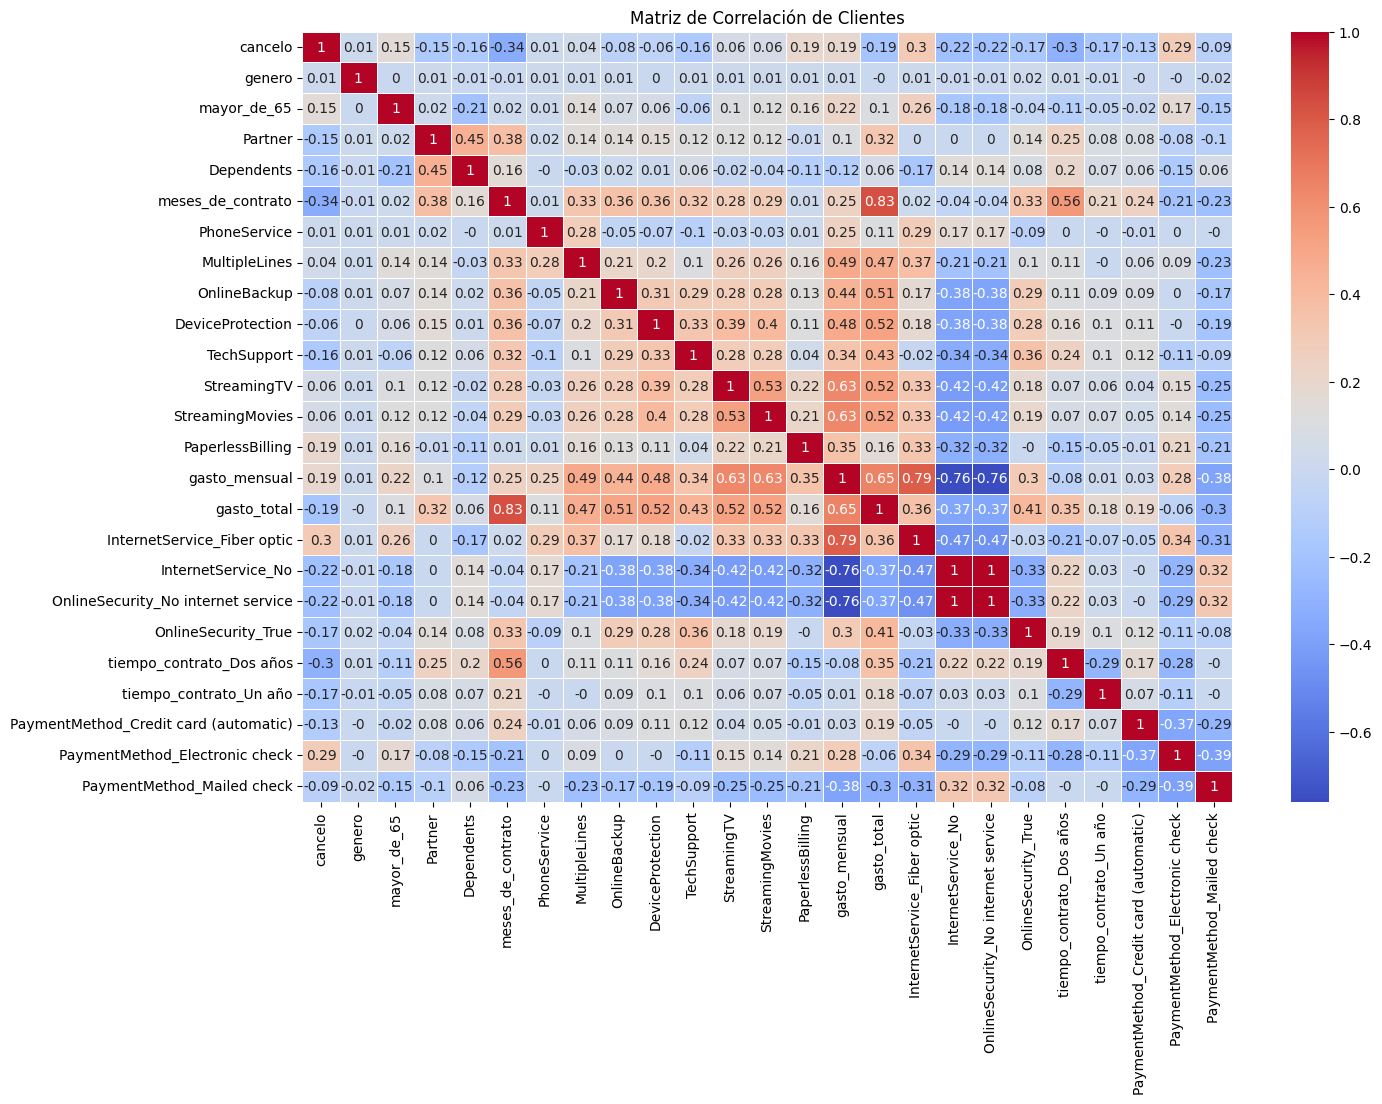

In [86]:
#Correlacion de manera ordenada
#print(corr_matrix['cancelo'].sort_values(ascending=False))

plt.figure(figsize=(15, 10))
sns.heatmap(np.round(corr_matrix,2), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Matriz de Correlación de Clientes")
plt.show()

**Relación de variables especificas con la cancelación de suscripciones**

/tmp/ipykernel_395/434125023.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cancelo', y='meses_de_contrato', data=df_final, palette='Set2')


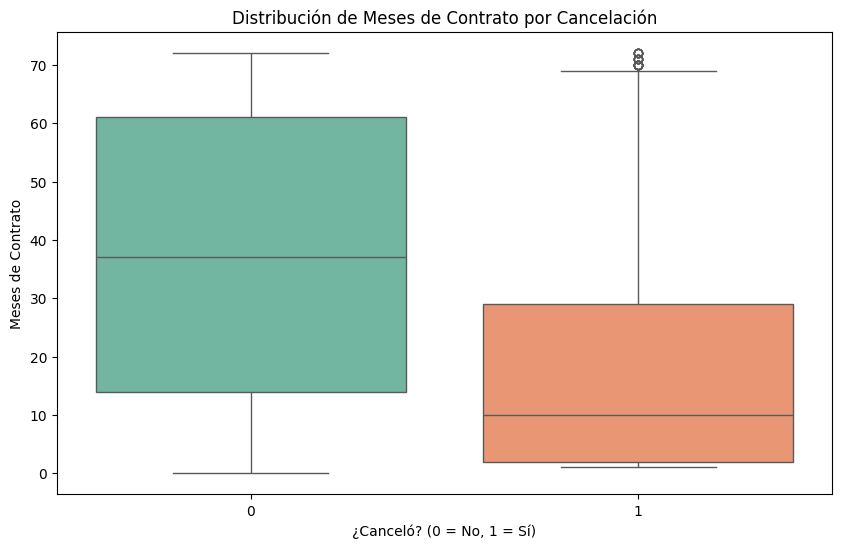

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='cancelo', y='meses_de_contrato', data=df_final, palette='Set2')
plt.title('Distribución de Meses de Contrato por Cancelación')
plt.xlabel('¿Canceló? (0 = No, 1 = Sí)')
plt.ylabel('Meses de Contrato')
plt.show()

/tmp/ipykernel_395/4055426844.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='cancelo', y='gasto_total', data=df_final, jitter=True, alpha=0.3, palette='viridis')


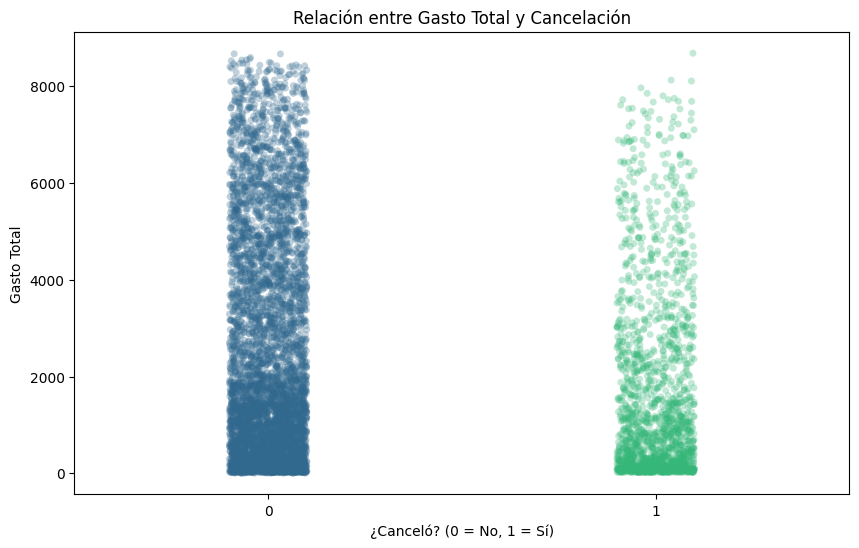

In [88]:
plt.figure(figsize=(10, 6))
sns.stripplot(x='cancelo', y='gasto_total', data=df_final, jitter=True, alpha=0.3, palette='viridis')
plt.title('Relación entre Gasto Total y Cancelación')
plt.xlabel('¿Canceló? (0 = No, 1 = Sí)')
plt.ylabel('Gasto Total')
plt.show()

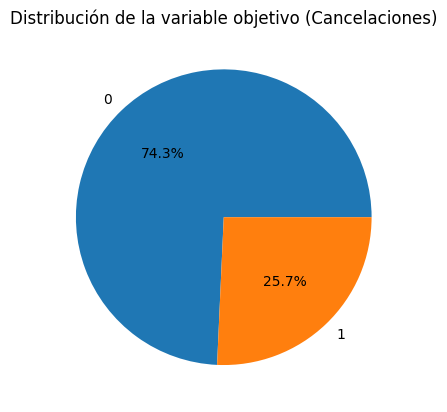

In [89]:
plt.pie(df_limpio['cancelo'].value_counts(), labels=df_limpio['cancelo'].value_counts().index, autopct='%1.1f%%')
plt.title('Distribución de la variable objetivo (Cancelaciones)')
plt.show()

#**Modelado predictivo 🤖**

**Separación de datos para entrenamiento y prueba 80/20**

In [90]:
from sklearn.model_selection import train_test_split

In [91]:
X = df_final.drop(columns=['cancelo'])
y = df_final['cancelo']

In [92]:
# Dividir - 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,      # 20% para prueba
    random_state=42,     # Semilla para que el resultado sea siempre el mismo
    stratify=y           # Mantiene la proporción de cancelaciones
)

print(f"Registros para entrenamiento: {len(X_train)}")
print(f"Registros para prueba: {len(X_test)}")

Registros para entrenamiento: 5813
Registros para prueba: 1454


##**Creación de dos modelos para predecir la cancelación de los clientes**

###**Regresión logística**

In [93]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [94]:
# 1. Normalización de los datos
scaler= StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

# 2. Creación y entrenamiento del modelo
modelo_log = LogisticRegression(random_state=42)
modelo_log.fit(X_train_scaled, y_train)

# 3. Predicciones
y_pred_log = modelo_log.predict(X_test_scaled)

###**Árbol de Decisión o Random Forest**

In [95]:
from sklearn.ensemble import RandomForestClassifier

In [96]:
# 1. Creación y entrenamiento del modelo (usamos X_train del inicio)
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

# 2. Predicciones
y_pred_rf = modelo_rf.predict(X_test)

##**Matrices de confusión para los modelos generados**

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [98]:
def graficar_confusion(y_real, y_pred, titulo):
    cm = confusion_matrix(y_real, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Se queda', 'Cancela'],
                yticklabels=['Se queda', 'Cancela'])
    plt.title(f'Matriz de Confusión: {titulo}')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción del Modelo')
    plt.show()

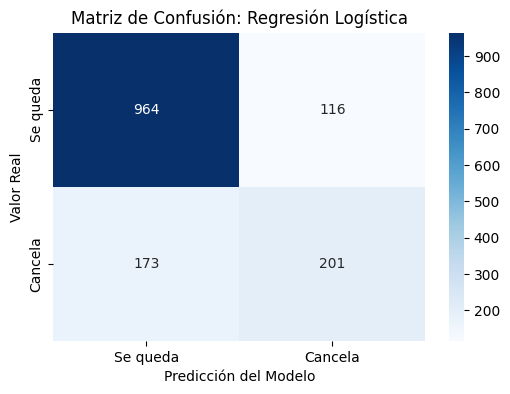

In [99]:
graficar_confusion(y_test, y_pred_log,"Regresión Logística")

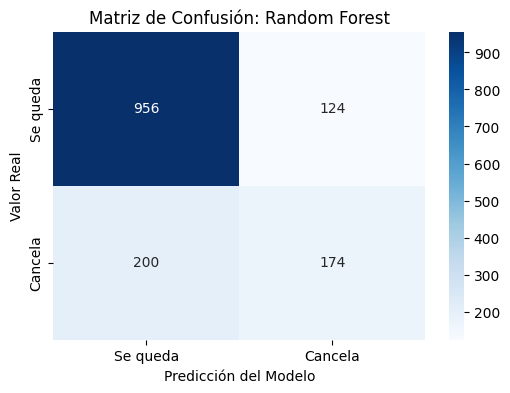

In [100]:
graficar_confusion(y_test, y_pred_rf,"Random Forest")

##**Evaluación de los modelos predictivos** ##

In [101]:
print("--- EVALUACIÓN REGRESIÓN LOGÍSTICA ---")
print(classification_report(y_test, y_pred_log))

print("\n--- EVALUACIÓN RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))

--- EVALUACIÓN REGRESIÓN LOGÍSTICA ---
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1080
           1       0.63      0.54      0.58       374

    accuracy                           0.80      1454
   macro avg       0.74      0.72      0.73      1454
weighted avg       0.79      0.80      0.80      1454


--- EVALUACIÓN RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1080
           1       0.58      0.47      0.52       374

    accuracy                           0.78      1454
   macro avg       0.71      0.68      0.69      1454
weighted avg       0.76      0.78      0.77      1454



##**Comprobación de los modelos con una gráfica ROC**

In [102]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

In [103]:
# 1. Obtener las probabilidades de predicción
# Tomamos la probabilidad de la clase 1 (cancelación)
probs_log = modelo_log.predict_proba(X_test_scaled)[:, 1]
probs_rf = modelo_rf.predict_proba(X_test)[:, 1]

# 2. Calcular los valores de la curva
fpr_log, tpr_log, _ = roc_curve(y_test, probs_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, probs_rf)

# 3. Calcular el AUC
auc_log = roc_auc_score(y_test, probs_log)
auc_rf = roc_auc_score(y_test, probs_rf)

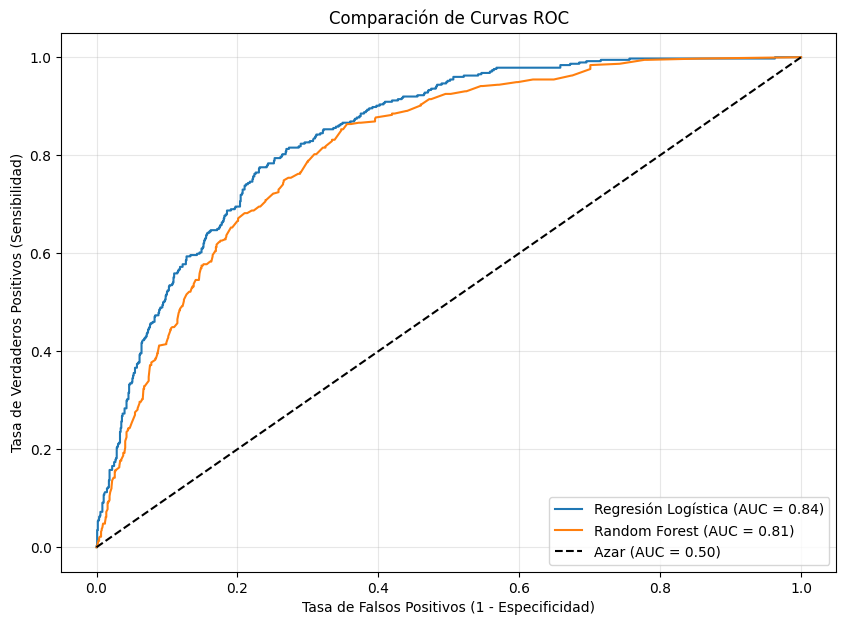

AUC Regresión Logística: 0.8438960685284215
AUC Random Forest: 0.8145362943157061
La Regresión Logística es mejor modelo para calcular las futuras cancelaciones de los clientes


In [104]:
plt.figure(figsize=(10, 7))
plt.plot(fpr_log, tpr_log, label=f'Regresión Logística (AUC = {auc_log:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')

# Línea base (azar)
plt.plot([0, 1], [0, 1], 'k--', label='Azar (AUC = 0.50)')

plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Comparación de Curvas ROC')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f"AUC Regresión Logística: {auc_log}")
print(f"AUC Random Forest: {auc_rf}")
print('La Regresión Logística es mejor modelo para calcular las futuras cancelaciones de los clientes')

#**Interpretación y conclusiones 📋**

##**Análisis de importancia de las variables**

In [107]:
import pandas as pd
import numpy as np

Regresión, los números indican las probabilidades de cancelación

- Positivo: A medida que aumenta la variable, aumenta la probabilidad de cancelación.

- Negativo: A medida que aumenta la variable, el cliente es más leal (disminuye la cancelación).

In [105]:
# Extraer coeficientes
importancias_log = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo_log.coef_[0]
})

# Ordenar por valor absoluto para ver las más influyentes
importancias_log['Abs_Coef'] = importancias_log['Coeficiente'].abs()
importancias_log = importancias_log.sort_values(by='Abs_Coef', ascending=False)

print(importancias_log[['Variable', 'Coeficiente']].head(10))

                              Variable  Coeficiente
4                    meses_de_contrato    -1.431930
14                         gasto_total     0.686416
15         InternetService_Fiber optic     0.590956
13                       gasto_mensual    -0.555992
19            tiempo_contrato_Dos años    -0.545897
20              tiempo_contrato_Un año    -0.257844
17  OnlineSecurity_No internet service    -0.247763
16                  InternetService_No    -0.247763
12                    PaperlessBilling     0.190313
10                         StreamingTV     0.179513


Árbol de decisiones, el gráfico indica las variables de mayor importancia que se relacionan con la retención de los clientes

/tmp/ipykernel_395/1050149099.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=importancias_rf.head(10), palette='magma')


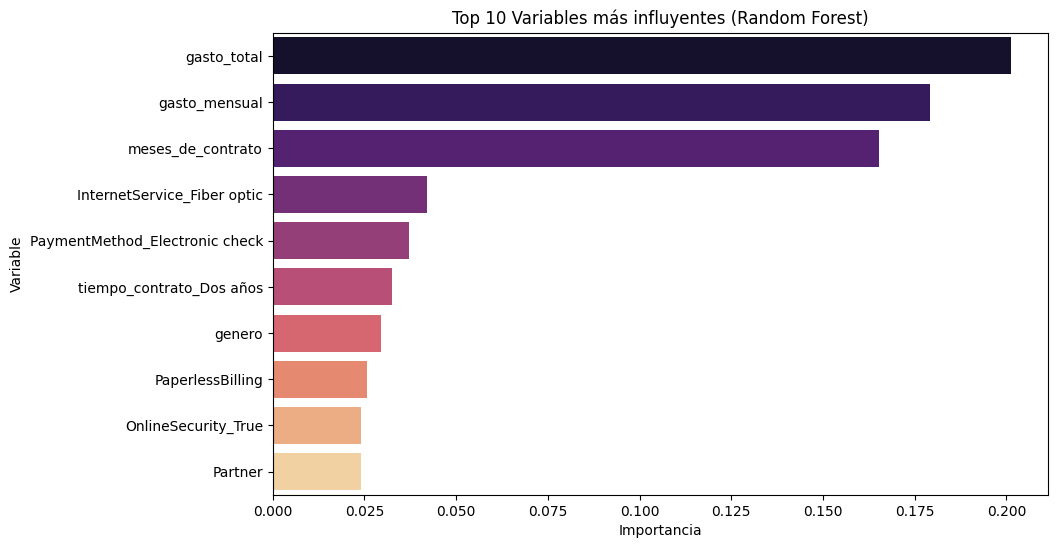

In [106]:
# Extraer importancia
importancias_rf = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo_rf.feature_importances_
})

importancias_rf = importancias_rf.sort_values(by='Importancia', ascending=False)

# Graficar
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=importancias_rf.head(10), palette='magma')
plt.title('Top 10 Variables más influyentes (Random Forest)')
plt.show()

#**Conclusiones**

Los modelos realizados para este proyecto permitieron descubrir los pricipales factores que determinan si un cliente realizara la cancelación de su servicio o, por el caso contrario, continuará renovando su suscripción.

De acuerdo con la información de la base de datos original, se hizo el análisis de las variables y se generarón dos modelos estadísticos para entender a los posibles clientes que cancelaran.

En primer lugar se uso el modelo de **Regresión Logística**, para en este caso, fue necesario normalizar los datos para evitar errores, ya que los valores de gasto_total serian muy altos al representar las ganancias generadas.

Por otro lado, el modelo de **Random Forest** suele ser más preciso porque consiste en generar cientos de 'árboles de decisión' que votan por un resultado, en este modelo no es necesario normalizar pero si mantener el uso de un dataframe limpio para evitar errores

**Estrategía de retención**
En el estudio de matrices de confusión podemos observar falsos negativos que son personas que cancelaron pero el modelo predijo que se quedarían, bajo esta condición se puede generar una campaña de retención a través del marketing de la plataforma, nuevos paquetes o cupones de descuento para evitar la fuga de los clientes.

De manera general, la empresa debe de supervisar si el gasto mensual de los clientes sube para proyectar si se quedarán y si el tiempo de contrato es poco hay una gran rpobabilidad de riesgo para cancelación. Asimismo los periodos de contrato que se renuevan cada mes son más riesgosos que los que cuentan con un plan a anual.